<a href="https://colab.research.google.com/github/maxsccavalcante/Cafeteria_POO/blob/main/Mall_Customers_Clusterizacao_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/maxsccavalcante/Topicos_Especiais_em_TI/blob/main/Mall_Customers_Clusterizacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='white'>Machine Learning Clusterização</font>

# <font color='white'>Clientes de Shopping</font>

A partir de dados de clientes de um shopping (idade, gênero, renda anual e pontuação de gastos), o trabalho é agrupar os consumidores por similaridade a fim de compreender o perfil de cada grupo e apoiar estratégias de marketing direcionadas.

Arquivo de dados: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

## Etapa 1 - Imports

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pylab
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist, pdist
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## Etapa 2 - Carregando os dados

In [3]:
# Carregando os dados
# Lembre-se: no Colab, o arquivo precisa estar na sessão (upload manual) ou no Google Drive montado
dataset = pd.read_csv('Mall_Customers.csv')

## Etapa 3 - Análise exploratória inicial

In [4]:
# Visualizando informações sobre o dataset (tipos de dados, quantidade de registros, memória)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
# Visualizando as primeiras linhas do dataset
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
# Verificando o formato do dataset (linhas, colunas)
dataset.shape

(200, 5)

In [7]:
# Verificando os tipos de cada coluna
dataset.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [8]:
# Checando se há valores missing
dataset.isnull().values.any()

np.False_

## Etapa 4 - Pré-processamento

In [9]:
# Remove a coluna CustomerID, pois é apenas um identificador e não ajuda a agrupar os clientes
dataset = dataset.drop('CustomerID', axis = 1)

In [10]:
# Codifica a variável categórica 'Gender' em numérica (0 = Male, 1 = Female),
# já que os algoritmos de clusterização trabalham apenas com números
dataset['Gender'] = dataset['Gender'].map({'Male': 0, 'Female': 1})

In [11]:
# Conferindo o resultado do pré-processamento
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [12]:
dataset.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [13]:
# Checando novamente se há valores missing após o pré-processamento
dataset.isnull().values.any()

np.False_

## Etapa 5 - Extração dos atributos

In [14]:
# Obtém os valores dos atributos como array numpy, formato exigido pelos algoritmos do scikit-learn
dataset_atrib = dataset.values

In [15]:
dataset_atrib

array([[  0,  19,  15,  39],
       [  0,  21,  15,  81],
       [  1,  20,  16,   6],
       [  1,  23,  16,  77],
       [  1,  31,  17,  40],
       [  1,  22,  17,  76],
       [  1,  35,  18,   6],
       [  1,  23,  18,  94],
       [  0,  64,  19,   3],
       [  1,  30,  19,  72],
       [  0,  67,  19,  14],
       [  1,  35,  19,  99],
       [  1,  58,  20,  15],
       [  1,  24,  20,  77],
       [  0,  37,  20,  13],
       [  0,  22,  20,  79],
       [  1,  35,  21,  35],
       [  0,  20,  21,  66],
       [  0,  52,  23,  29],
       [  1,  35,  23,  98],
       [  0,  35,  24,  35],
       [  0,  25,  24,  73],
       [  1,  46,  25,   5],
       [  0,  31,  25,  73],
       [  1,  54,  28,  14],
       [  0,  29,  28,  82],
       [  1,  45,  28,  32],
       [  0,  35,  28,  61],
       [  1,  40,  29,  31],
       [  1,  23,  29,  87],
       [  0,  60,  30,   4],
       [  1,  21,  30,  73],
       [  0,  53,  33,   4],
       [  0,  18,  33,  92],
       [  1,  

## Etapa 6 - Amostragem

In [16]:
# O dataset de clientes do shopping tem apenas 200 registros (bem diferente do dataset de energia,
# que tinha milhões de linhas). Por isso, NÃO precisamos reduzir a amostra para 1%: usamos todos os dados.
amostra1 = dataset_atrib

In [17]:
amostra1.shape

(200, 4)

## Etapa 7 - Redução de dimensionalidade (PCA)

In [18]:
# Aplica redução de dimensionalidade
# Transforma as 4 variáveis (Gender, Age, Annual Income, Spending Score) em 2 variáveis principais.
# Esse método utiliza Álgebra Linear para identificar semelhança entre os dados e assim "juntar" as
# variáveis, medindo a semelhança pela variância.
pca = PCA(n_components = 2).fit_transform(amostra1)

## Etapa 8 - Definindo o range de valores de K

In [19]:
# Determinando um range de K a ser testado
k_range = range(1, 12)

In [20]:
# Aplicando o modelo K-Means para cada valor de K
k_means_var = [KMeans(n_clusters = k).fit(pca) for k in k_range]

## Etapa 9 - Cálculo das distâncias para a curva de Elbow

In [21]:
# Ajustando o centróide do cluster para cada modelo
centroids = [X.cluster_centers_ for X in k_means_var]

In [22]:
# Calculando a distância euclidiana de cada ponto de dado para o centróide
k_euclid = [cdist(pca, cent, 'euclidean') for cent in centroids]
dist = [np.min(ke, axis = 1) for ke in k_euclid]

In [23]:
# Soma dos quadrados das distâncias dentro do cluster
soma_quadrados_intra_cluster = [sum(d**2) for d in dist]

In [24]:
# Soma total dos quadrados
soma_total = sum(pdist(pca)**2) / pca.shape[0]

In [25]:
# Soma dos quadrados entre clusters
soma_quadrados_inter_cluster = soma_total - soma_quadrados_intra_cluster

## Etapa 10 - Curva de Elbow

Text(0.5, 1.0, 'Variância Explicada x Valor de K')

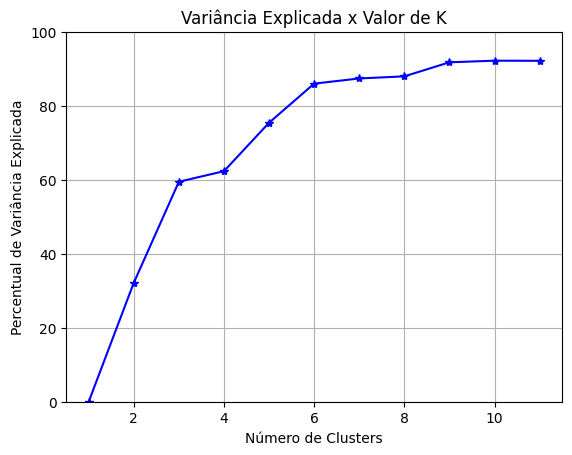

In [26]:
# Curva de Elbow
# ATENÇÃO: rode esta célula e observe o gráfico. Escolha o valor de K (número de clusters) no ponto
# onde a curva "dobra" (o "cotovelo") - a partir dali, adicionar mais clusters explica pouca variância a mais.
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(k_range, soma_quadrados_inter_cluster / soma_total * 100, 'b*-')
ax.set_ylim((0, 100))
plt.grid(True)
plt.xlabel('Número de Clusters')
plt.ylabel('Percentual de Variância Explicada')
plt.title('Variância Explicada x Valor de K')

## Etapa 11 - Criando o modelo final (versão 1)

**Ajuste o valor de `n_clusters` abaixo de acordo com o K que você identificou na curva de Elbow.** Para este dataset, o valor mais citado na literatura é K = 5, mas confirme observando o seu gráfico.

In [27]:
# Criando um modelo com o K escolhido a partir da curva de Elbow
modelo_v1 = KMeans(n_clusters = 5)
modelo_v1.fit(pca)

KMeans(n_clusters=5)

## Etapa 12 - Visualizando as regiões dos clusters

In [28]:
# Obtém os valores mínimos e máximos e organiza o shape da malha (grid) de pontos
x_min, x_max = pca[:, 0].min() - 1, pca[:, 0].max() + 1
y_min, y_max = pca[:, 1].min() - 1, pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, .02), np.arange(y_min, y_max, .02))
Z = modelo_v1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

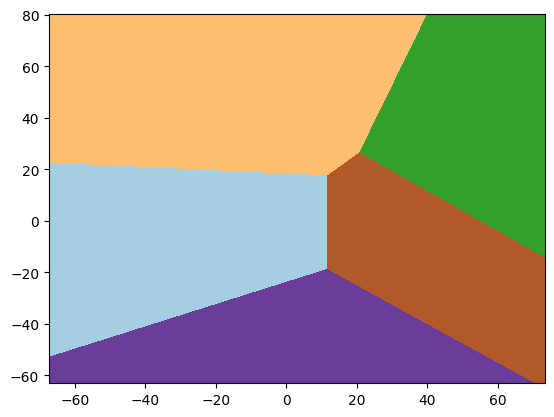

In [29]:
# Plot das áreas de cada cluster
plt.figure(1)
plt.clf()
plt.imshow(Z,
           interpolation = 'nearest',
           extent = (xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Paired,
           aspect = 'auto',
           origin = 'lower')

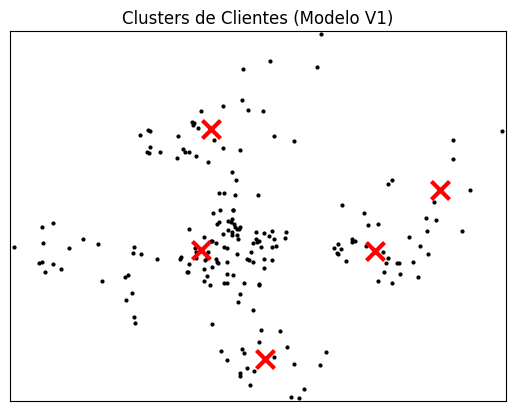

In [30]:
# Plot dos pontos de dados e dos centróides de cada cluster
plt.plot(pca[:, 0], pca[:, 1], 'k.', markersize = 4)
centroids = modelo_v1.cluster_centers_
inert = modelo_v1.inertia_
plt.scatter(centroids[:, 0], centroids[:, 1], marker = 'x', s = 169, linewidths = 3, color = 'r', zorder = 8)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.title('Clusters de Clientes (Modelo V1)')
plt.show()

## Etapa 13 - Avaliando o modelo (Silhouette Score)

In [31]:
# Silhouette Score -- usado para avaliar se o número de clusters é bom.
# Quanto mais próximo de 1, melhor a separação dos clusters. Quanto mais próximo de -1, pior.
labels = modelo_v1.labels_
silhouette_score(pca, labels, metric = 'euclidean')

np.float64(0.4659602553328676)

## Etapa 14 - Testando um segundo valor de K, para comparação

Troque o `n_clusters` abaixo por outro valor próximo ao escolhido na Etapa 11 (por exemplo, um a mais ou um a menos) e compare o Silhouette Score com o da Etapa 13.

In [32]:
# Criando um segundo modelo, com outro valor de K, para comparar o resultado
modelo_v2 = KMeans(n_clusters = 6)
modelo_v2.fit(pca)

KMeans(n_clusters=6)

In [33]:
# Obtém os valores mínimos e máximos e organiza o shape da malha
x_min, x_max = pca[:, 0].min() - 1, pca[:, 0].max() + 1
y_min, y_max = pca[:, 1].min() - 1, pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, .02), np.arange(y_min, y_max, .02))
Z = modelo_v2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

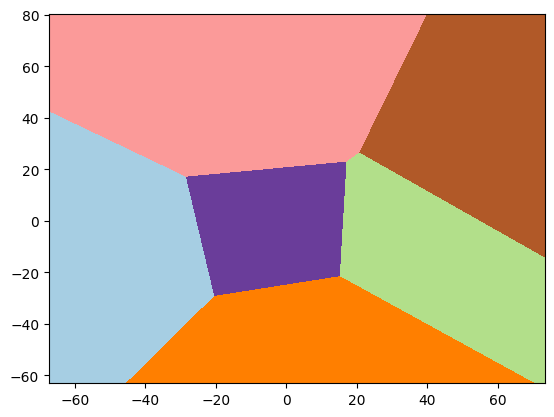

In [34]:
# Plot das áreas de cada cluster
plt.figure(1)
plt.clf()
plt.imshow(Z,
           interpolation = 'nearest',
           extent = (xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Paired,
           aspect = 'auto',
           origin = 'lower')

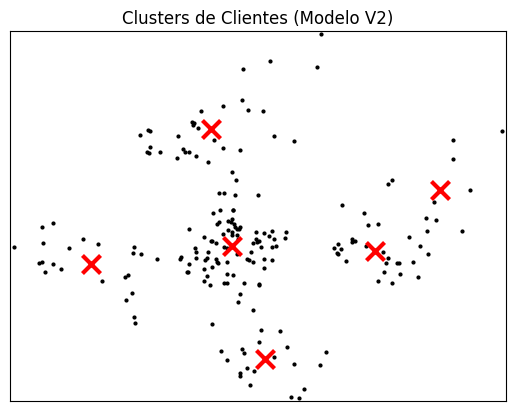

In [35]:
# Plot dos pontos de dados e dos centróides
plt.plot(pca[:, 0], pca[:, 1], 'k.', markersize = 4)
centroids = modelo_v2.cluster_centers_
inert = modelo_v2.inertia_
plt.scatter(centroids[:, 0], centroids[:, 1], marker = 'x', s = 169, linewidths = 3, color = 'r', zorder = 8)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.title('Clusters de Clientes (Modelo V2)')
plt.show()

In [36]:
# Silhouette Score do modelo V2, para comparar com o modelo V1
labels = modelo_v2.labels_
silhouette_score(pca, labels, metric = 'euclidean')

np.float64(0.5344483744329873)

## Etapa 15 - Cluster Map

A partir daqui, seguimos com o modelo que apresentou o **melhor Silhouette Score** entre a Etapa 13 e a Etapa 14. Ajuste `modelo_v1` para `modelo_v2` abaixo, se necessário.

In [37]:
# Lista com os nomes das colunas originais (na mesma ordem usada em dataset_atrib)
names = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

In [38]:
# Cria o cluster map: reúne os dados originais (não o PCA) com o rótulo de cluster de cada cliente
cluster_map = pd.DataFrame(amostra1, columns = names)
cluster_map['cluster'] = modelo_v1.labels_

In [39]:
cluster_map

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,0,19,15,39,0
1,0,21,15,81,3
2,1,20,16,6,0
3,1,23,16,77,3
4,1,31,17,40,0
...,...,...,...,...,...
195,1,35,120,79,1
196,1,45,126,28,2
197,0,32,126,74,1
198,0,32,137,18,2


## Etapa 16 - Analisando o perfil de cada cluster

In [40]:
# Calcula a média de idade, renda anual e pontuação de gastos por cluster,
# para entender o perfil de cada grupo de clientes
cluster_map.groupby('cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,43.076190,49.085714,43.057143
1,32.454545,108.181818,82.727273
2,41.647059,88.735294,16.764706
3,25.272727,25.727273,79.363636
4,32.785714,78.035714,81.892857


In [41]:
# Calcula a quantidade de clientes em cada cluster
cluster_map.groupby('cluster')['Gender'].count()

,Gender
cluster,
0,105
1,11
2,34
3,22
4,28


## Etapa 17 - Gerando o cluster com dados normalizados

As variáveis originais têm escalas bem diferentes (Idade vai até ~70, Renda Anual até ~140, Pontuação de Gastos até 100). Isso pode fazer a variável de maior escala dominar o PCA e o K-Means. Nesta etapa, normalizamos os dados para o intervalo [0, 1] antes de repetir o processo, e comparamos o resultado.

In [42]:
# Obtém novamente os valores dos atributos originais (não normalizados)
dataset_atrib = dataset.values

# Importa a biblioteca para normalização
from sklearn.preprocessing import MinMaxScaler

# Cria o objeto normalizador e normaliza os dados para o intervalo [0, 1]
Padronizador = MinMaxScaler()
dataset_atrib_norm = Padronizador.fit_transform(dataset_atrib)

In [43]:
# Repete o pipeline completo (PCA -> K-Means -> Silhouette -> Cluster Map) com os dados normalizados
amostra1_norm = dataset_atrib_norm
pca_norm = PCA(n_components = 2).fit_transform(amostra1_norm)

k_range = range(1, 12)
k_means_var = [KMeans(n_clusters = k).fit(pca_norm) for k in k_range]
centroids = [X.cluster_centers_ for X in k_means_var]
k_euclid = [cdist(pca_norm, cent, 'euclidean') for cent in centroids]
dist = [np.min(ke, axis = 1) for ke in k_euclid]
soma_quadrados_intra_cluster = [sum(d**2) for d in dist]
soma_total = sum(pdist(pca_norm)**2) / pca_norm.shape[0]
# Soma dos quadrados entre clusters
soma_quadrados_inter_cluster = soma_total - soma_quadrados_intra_cluster

Text(0.5, 1.0, 'Variância Explicada x Valor de K (dados normalizados)')

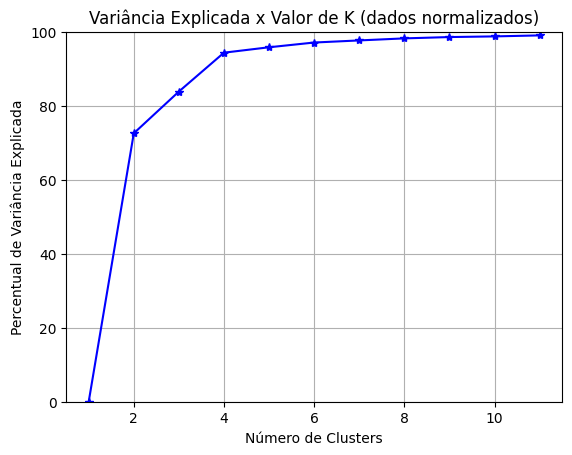

In [44]:
# Curva de Elbow com os dados normalizados -- confira se o K ideal muda em relação à versão sem normalizar
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(k_range, soma_quadrados_inter_cluster / soma_total * 100, 'b*-')
ax.set_ylim((0, 100))
plt.grid(True)
plt.xlabel('Número de Clusters')
plt.ylabel('Percentual de Variância Explicada')
plt.title('Variância Explicada x Valor de K (dados normalizados)')

In [47]:
# Cria o modelo final com dados normalizados (ajuste o K conforme a curva de Elbow acima)
modelo_v3 = KMeans(n_clusters = 5)
modelo_v3.fit(pca_norm)

# Silhouette Score do modelo com dados normalizados
labels = modelo_v3.labels_
silhouette_score(pca_norm, labels, metric = 'euclidean')

np.float64(0.6469577702553923)

In [46]:
# Cluster map com os dados normalizados
cluster_map_norm = pd.DataFrame(amostra1_norm, columns = names)
cluster_map_norm['cluster'] = modelo_v3.labels_

# Quantidade de observações por cluster
cluster_map_norm.groupby('cluster')['Gender'].count()

,Gender
cluster,
0,57
1,28
2,39
3,55
4,21
